In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
data = np.array([120, 125, 128, 132, 135, 140, 145, 150, 155, 160, 165, 170])

scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data.reshape(-1,1))


X = []
y = []

time_step = 3

for i in range(len(data_scaled)-time_step):
    X.append(data_scaled[i:i+time_step])
    y.append(data_scaled[i+time_step])

X = np.array(X)
y = np.array(y)


In [ ]:
model = Sequential()

model.add(LSTM(
    50,
    activation='relu',
    input_shape=(time_step,1)
))

model.add(Dense(25))

model.add(Dense(1))


model.compile(
    optimizer='adam',
    loss='mse'
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3625
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2578 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1785 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1116 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0646 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0328
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0206 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0175 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0131 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0084 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0055
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.4396e-04
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7933e-04 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.5365e-04 
Epoch 16

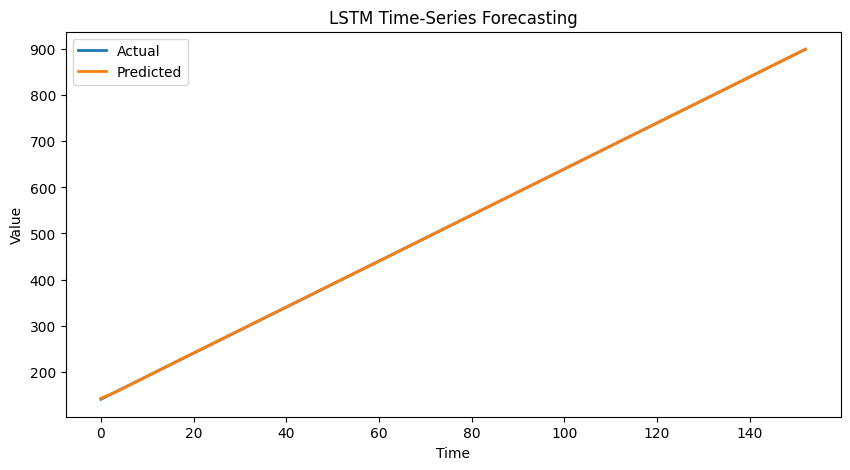

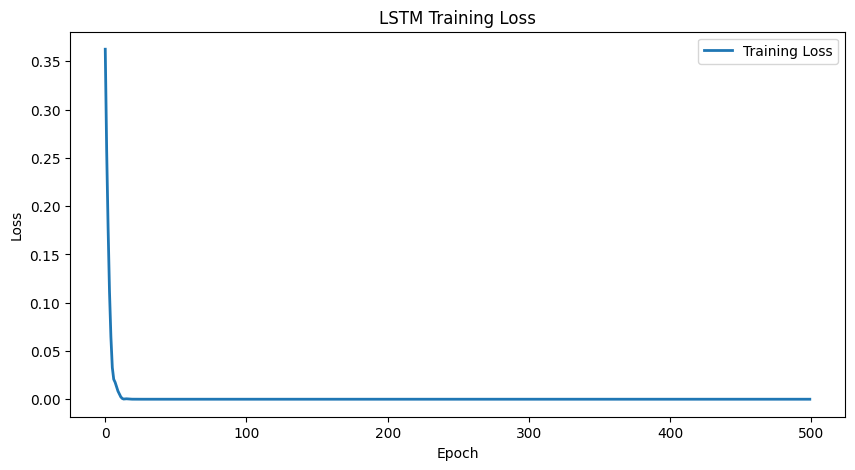

In [ ]:
model.fit(
    X,
    y,
    epochs=300,
    verbose=1
)


predicted = model.predict(X)

predicted = scaler.inverse_transform(predicted)

actual = scaler.inverse_transform(y)


plt.figure(figsize=(10,5))

plt.plot(actual,
         label='Actual',
         linewidth=2)

plt.plot(predicted,
         label='Predicted',
         linewidth=2)

plt.title("LSTM Time-Series Forecasting")

plt.xlabel("Time")

plt.ylabel("Value")

plt.legend()

plt.show()